Start playing with Python

Group 12

Simone Cerrone (Matr: 303432)

Mohamad Ternanni (Matr: 298496)

Filippo Tacconi (Matr: 314998)

Vittoria Tomasini (Matr:304183)

a)

In [73]:
import pandas as pd
# create data
data ={
    'Col0': [1,3,5,7,9,11],
    'Col1': [2,4,6,8,10,12]
}
# create a data frame and impose labels for rows
df = pd.DataFrame(data, index =['Idx0','Idx1','Idx2','Idx3','Idx4','Idx5'])
print(df)

# we modify the data through the labels
print('\nNew matrix:\n')
df.at[('Idx0','Col1')] += 2;
df.at[('Idx2','Col1')] += 1;
print(df)




      Col0  Col1
Idx0     1     2
Idx1     3     4
Idx2     5     6
Idx3     7     8
Idx4     9    10
Idx5    11    12

New matrix:

      Col0  Col1
Idx0     1     4
Idx1     3     4
Idx2     5     7
Idx3     7     8
Idx4     9    10
Idx5    11    12


b)

In [74]:
import numpy as np

# define the variable x
x = 0.4
num = x * np.sinh(x)
den = 1 + np.exp((x**2)/2)
result  = np.log(num/den)
print(f"{result:.6f}")

-2.540003


c)

In [75]:
from scipy.optimize import minimize_scalar
import numpy as np

# 1. Define the function f(x)
def f(x):
    mu = 1
    return x * np.exp(-(x - mu)**2 / 2)

# 2. Use minimize_scalar on the negative function to find the peak
# We search within a chosen reasonable range, 0 to 5
res = minimize_scalar(lambda x: -f(x), bounds=(0, 5), method='bounded')

print(f"The maximum occurs at x = {res.x:.4f}")
print(f"The maximum value of the function is {f(res.x):.4f}")

The maximum occurs at x = 1.6180
The maximum value of the function is 1.3367


d)

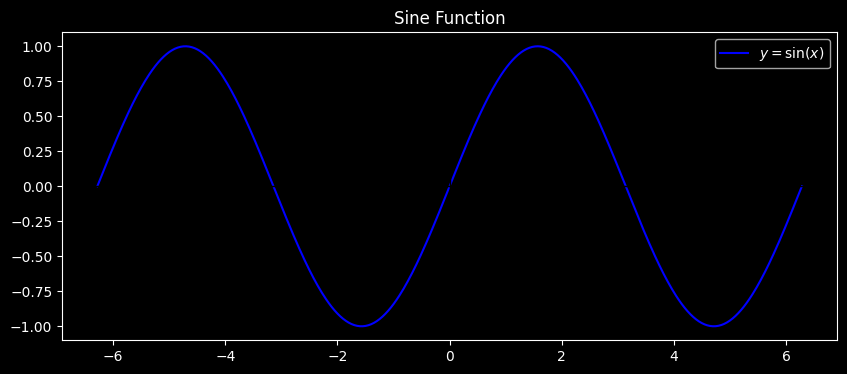

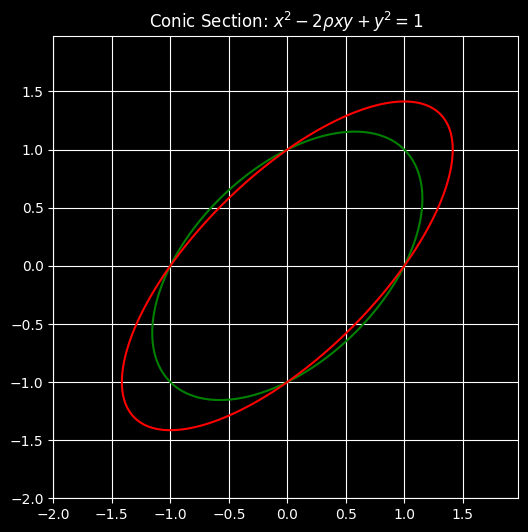

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Plot y = sin(x)
x_sin = np.linspace(-2 * np.pi, 2 * np.pi, 500)
y_sin = np.sin(x_sin)
# create the figure
plt.figure(figsize=(10, 4))
plt.plot(x_sin, y_sin,color = 'blue',label=r'$y = \sin(x)$')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Sine Function')
plt.legend()
plt.show()

# 2. Plot Conic Section x^2 - 2pxy + y^2 = 1
def plot_conic(rho, label):
    delta = 0.025
    x = np.arange(-2.0, 2.0, delta)
    y = np.arange(-2.0, 2.0, delta)
    X, Y = np.meshgrid(x, y)
    Z = X**2 - 2*rho*X*Y + Y**2
    plt.contour(X, Y, Z, [1], colors=[label])

plt.figure(figsize=(6, 6))
plot_conic(1/2,'green') # rho = 1/2
plot_conic(1/np.sqrt(2), 'red') # rho = 1/sqrt(2)
plt.title(r'Conic Section: $x^2 - 2\rho xy + y^2 = 1$')
plt.grid(True) # add grid
plt.show()

e)

In [77]:
import pandas as pd
import statsmodels.api as sm

# Data from Exercise A (first 5 rows)
data = {
    'Col0': [1, 3, 5, 7, 9],
    'Col1': [2, 4, 6, 8, 10]
}
df = pd.DataFrame(data)

# Define X and y
X = df['Col0']
y = df['Col1']
X = sm.add_constant(X) # Adds the intercept term

# Fit the model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Col1   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.415e+30
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.88e-46
Time:                        15:54:27   Log-Likelihood:                 159.86
No. Observations:                   5   AIC:                            -315.7
Df Residuals:                       3   BIC:                            -316.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0000    3.7e-15    2.7e+14      0.0

/Users/filippotacconi/PyCharmMiscProject/.venv/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


f)

In [78]:
import QuantLib as ql

# 1. Yearfrac 30/360 European
start_date = ql.Date(19, 2, 2008)
end_date = ql.Date(19, 5, 2008)
day_count = ql.Thirty360(ql.Thirty360.European)

year_frac = day_count.yearFraction(start_date, end_date)
print(f"Year Fraction (30/360 European): {year_frac:.6f}") #90/360

# 2. Monthly Modified Adjusted Calendar
start_sched = ql.Date(31, 10, 2025)
end_sched = start_sched + ql.Period(6, ql.Months)
# considering a relevant calendar
calendar = ql.UnitedStates(ql.UnitedStates.Settlement)
schedule = ql.Schedule(start_sched,
                       end_sched,
                       ql.Period(ql.Monthly),
                       calendar,
                       ql.ModifiedFollowing,
                       ql.ModifiedFollowing,
                       ql.DateGeneration.Forward,
                       False)

print("Monthly Schedule (Modified Following):")
for i, d in enumerate(schedule):
    print(f"Month {i}: {d}")

Year Fraction (30/360 European): 0.250000
Monthly Schedule (Modified Following):
Month 0: October 31st, 2025
Month 1: November 28th, 2025
Month 2: December 31st, 2025
Month 3: January 30th, 2026
Month 4: February 27th, 2026
Month 5: March 31st, 2026
Month 6: April 30th, 2026
